In [26]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [27]:
df = pd.read_csv('emails.csv')

In [28]:
display_cols = ['Email No.', 'the', 'to', 'subject', 'ect', 'Prediction']
df[display_cols].head(10)

,Email No.,the,to,subject,ect,Prediction
0,Email 1,0,0,0,1,0
1,Email 2,8,13,3,24,0
2,Email 3,0,0,0,1,0
3,Email 4,0,5,3,22,0
4,Email 5,7,6,2,17,0
5,Email 6,4,5,0,1,1
6,Email 7,5,3,0,1,0
7,Email 8,0,2,0,2,1
8,Email 9,2,2,0,3,0
9,Email 10,4,4,1,35,0


In [29]:
df[display_cols].head()

,Email No.,the,to,subject,ect,Prediction
0,Email 1,0,0,0,1,0
1,Email 2,8,13,3,24,0
2,Email 3,0,0,0,1,0
3,Email 4,0,5,3,22,0
4,Email 5,7,6,2,17,0


In [30]:
df.shape

(5172, 3002)

In [31]:
df.isna().sum()[df.isna().sum() > 0]

Series([], dtype: int64)

In [32]:
print(f'Total missing values: {df.isna().sum().sum()}')

Total missing values: 0


In [33]:
df.duplicated().sum()

np.int64(0)

In [34]:
df.info(verbose=False)

<class 'pandas.DataFrame'>
RangeIndex: 5172 entries, 0 to 5171
Columns: 3002 entries, Email No. to Prediction
dtypes: int64(3001), str(1)
memory usage: 118.5 MB


In [35]:
key_cols = ['Email No.', 'the', 'to', 'subject', 'Prediction']
df[key_cols].nunique()

Email No.     5172
the             90
to              72
subject         15
Prediction       2
dtype: int64

In [36]:
top_word_cols = df.drop(columns=['Email No.', 'Prediction']).sum().nlargest(10).index.tolist()
df[top_word_cols + ['Prediction']].describe()

,e,t,a,o,n,i,r,s,l,c,Prediction
count,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000,5172.000000
mean,84.795244,60.477765,55.517401,55.098608,48.100735,45.857889,45.412606,41.811872,30.997100,29.909126,0.290023
std,126.845509,94.815319,87.574172,85.300764,76.875463,77.832221,71.567911,66.530032,47.756507,51.642923,0.453817
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,18.000000,12.000000,12.000000,11.000000,10.000000,8.000000,9.000000,8.000000,7.000000,5.000000,0.000000
50%,42.000000,29.000000,28.000000,27.000000,23.000000,22.000000,22.000000,20.000000,16.000000,13.000000,0.000000
75%,97.000000,68.000000,62.250000,63.000000,53.000000,49.000000,53.000000,46.000000,35.000000,33.000000,1.000000
max,2327.000000,1299.000000,1898.000000,1751.000000,1232.000000,972.000000,1555.000000,882.000000,1038.000000,1254.000000,1.000000


In [37]:
print(f'Categories in Prediction column: {df["Prediction"].unique()}')
print('  0 = Not Spam,  1 = Spam')

Categories in Prediction column: [0 1]
  0 = Not Spam,  1 = Spam


In [38]:

numeric_features = [c for c in df.columns if df[c].dtype != 'O' and c not in ['Email No.']]
categorical_features = [c for c in df.columns if df[c].dtype == 'O' and c not in ['Email No.']]

print(f'We have {len(numeric_features)} numerical features')
print(f'We have {len(categorical_features)} categorical features (excluding Email No.)')

We have 3001 numerical features
We have 0 categorical features (excluding Email No.)


In [39]:
word_cols = [c for c in df.columns if c not in ['Email No.', 'Prediction']]
df['total_word_count'] = df[word_cols].sum(axis=1)
df['avg_word_freq']    = df['total_word_count'] / len(word_cols)
df[['Email No.', 'total_word_count', 'avg_word_freq', 'Prediction']].head()

,Email No.,total_word_count,avg_word_freq,Prediction
0,Email 1,53,0.017667,0
1,Email 2,2203,0.734333,0
2,Email 3,113,0.037667,0
3,Email 4,1019,0.339667,0
4,Email 5,1075,0.358333,0


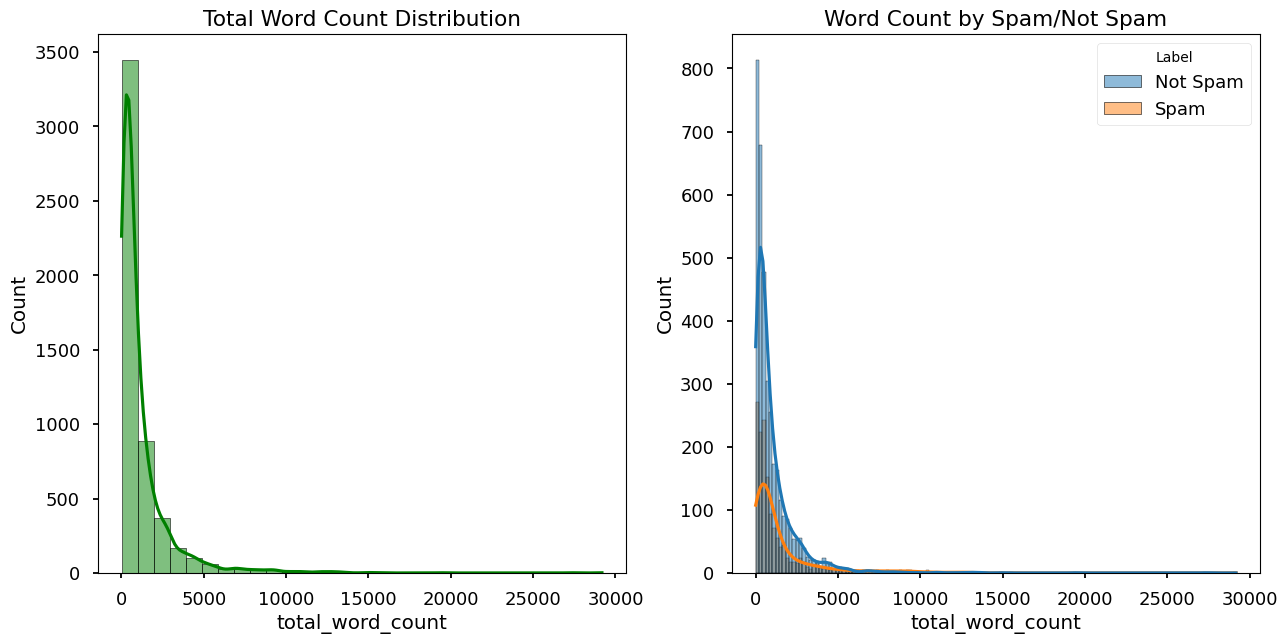

In [40]:
temp_df = df.copy()
temp_df['Label'] = temp_df['Prediction'].map({0: 'Not Spam', 1: 'Spam'})

fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df, x='total_word_count', bins=30, kde=True, color='g')
plt.title('Total Word Count Distribution')
plt.subplot(122)
sns.histplot(data=temp_df, x='total_word_count', kde=True, hue='Label')
plt.title('Word Count by Spam/Not Spam')
plt.show()

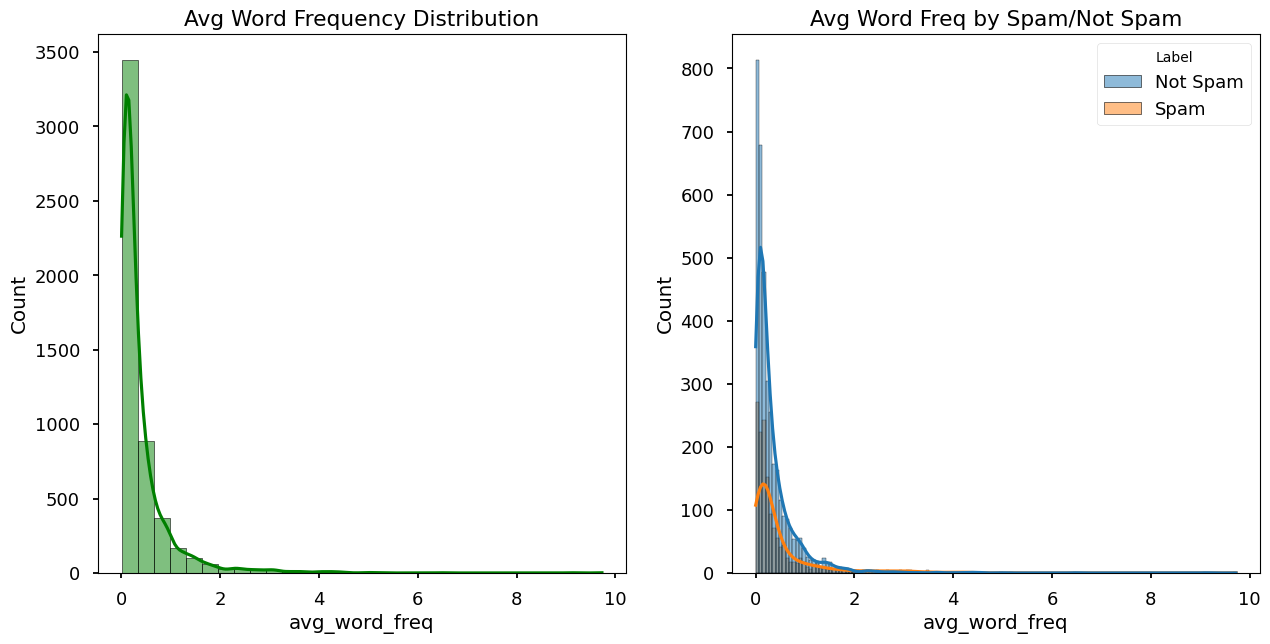

In [41]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df, x='avg_word_freq', bins=30, kde=True, color='g')
plt.title('Avg Word Frequency Distribution')
plt.subplot(122)
sns.histplot(data=temp_df, x='avg_word_freq', kde=True, hue='Label')
plt.title('Avg Word Freq by Spam/Not Spam')
plt.show()

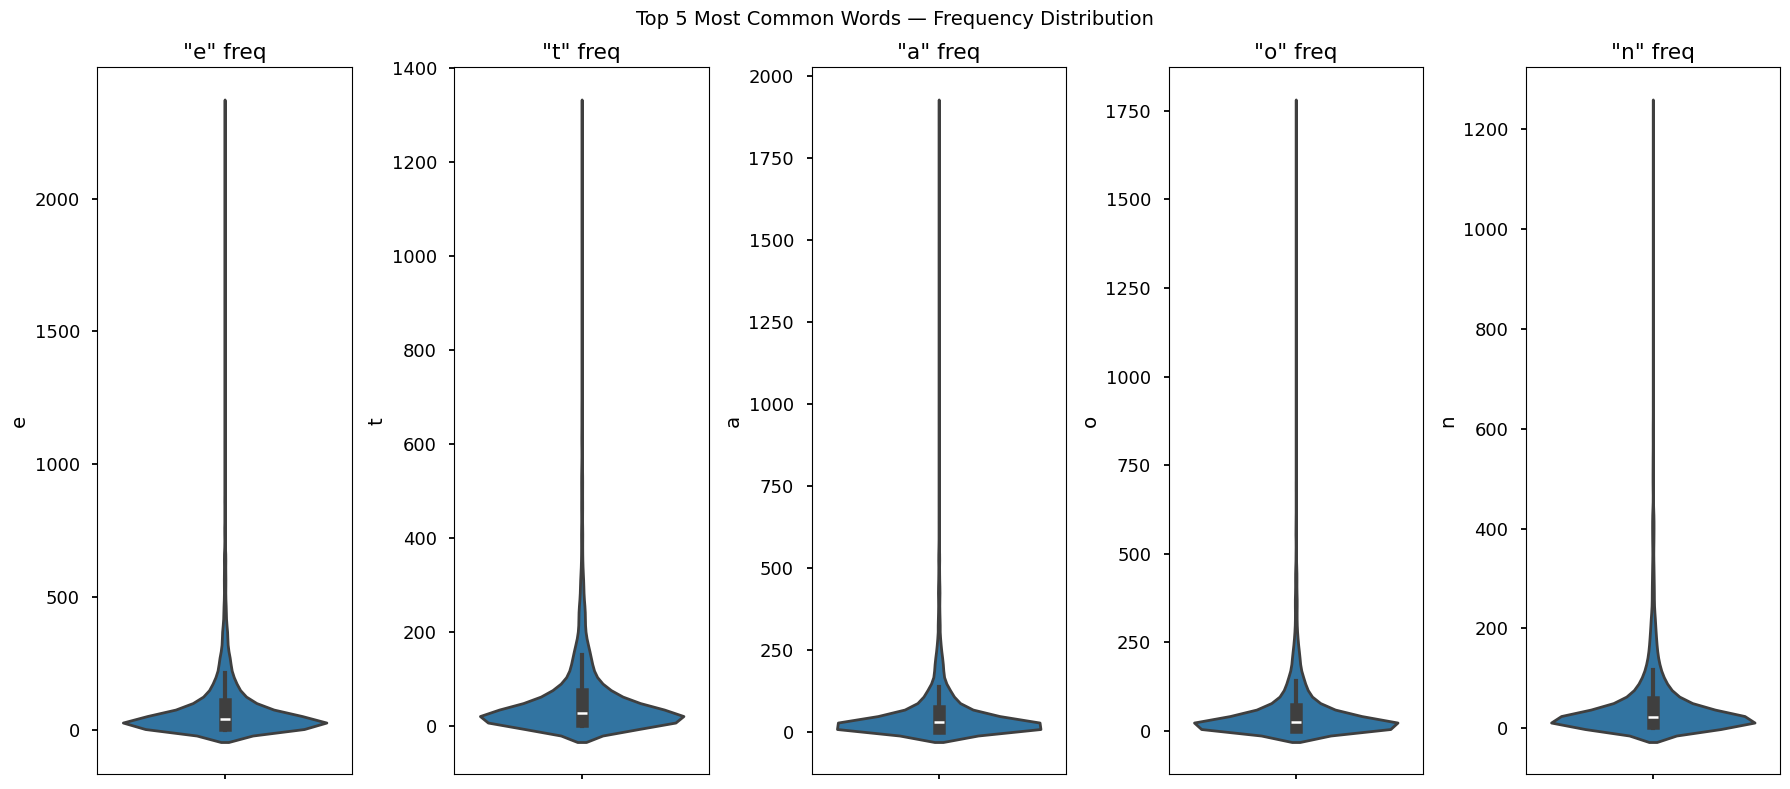

In [42]:
top5_words = df[word_cols].sum().nlargest(5).index.tolist()

fig, axes = plt.subplots(1, len(top5_words), figsize=(18, 8))
for i, word in enumerate(top5_words):
    sns.violinplot(y=df[word], ax=axes[i], linewidth=2)
    axes[i].set_title(f'"{word}" freq')
plt.suptitle('Top 5 Most Common Words — Frequency Distribution', fontsize=14)
plt.tight_layout()
plt.show()

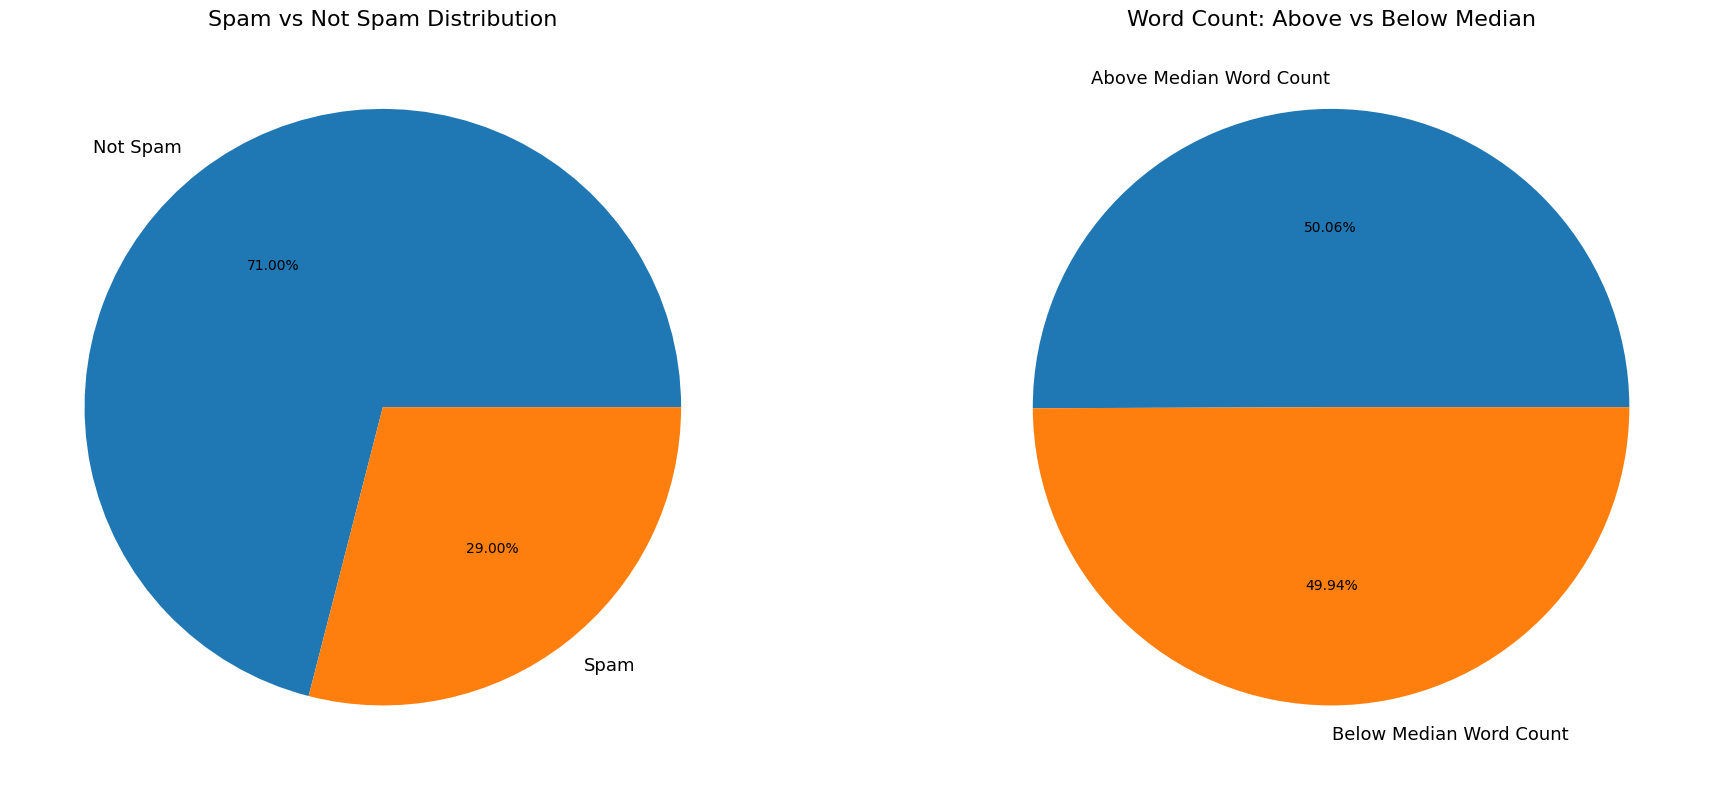

In [43]:
plt.rcParams['figure.figsize'] = (20, 8)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

size = df['Prediction'].value_counts()
axes[0].pie(size.values, labels=['Not Spam', 'Spam'], autopct='%1.2f%%')
axes[0].set_title('Spam vs Not Spam Distribution', fontsize=16)
axes[0].axis('off')

median_wc = df['total_word_count'].median()
wc_cat = (df['total_word_count'] > median_wc).value_counts()
axes[1].pie(wc_cat.values,
            labels=['Above Median Word Count', 'Below Median Word Count'],
            autopct='%1.2f%%')
axes[1].set_title('Word Count: Above vs Below Median', fontsize=16)
axes[1].axis('off')

plt.tight_layout()
plt.show()

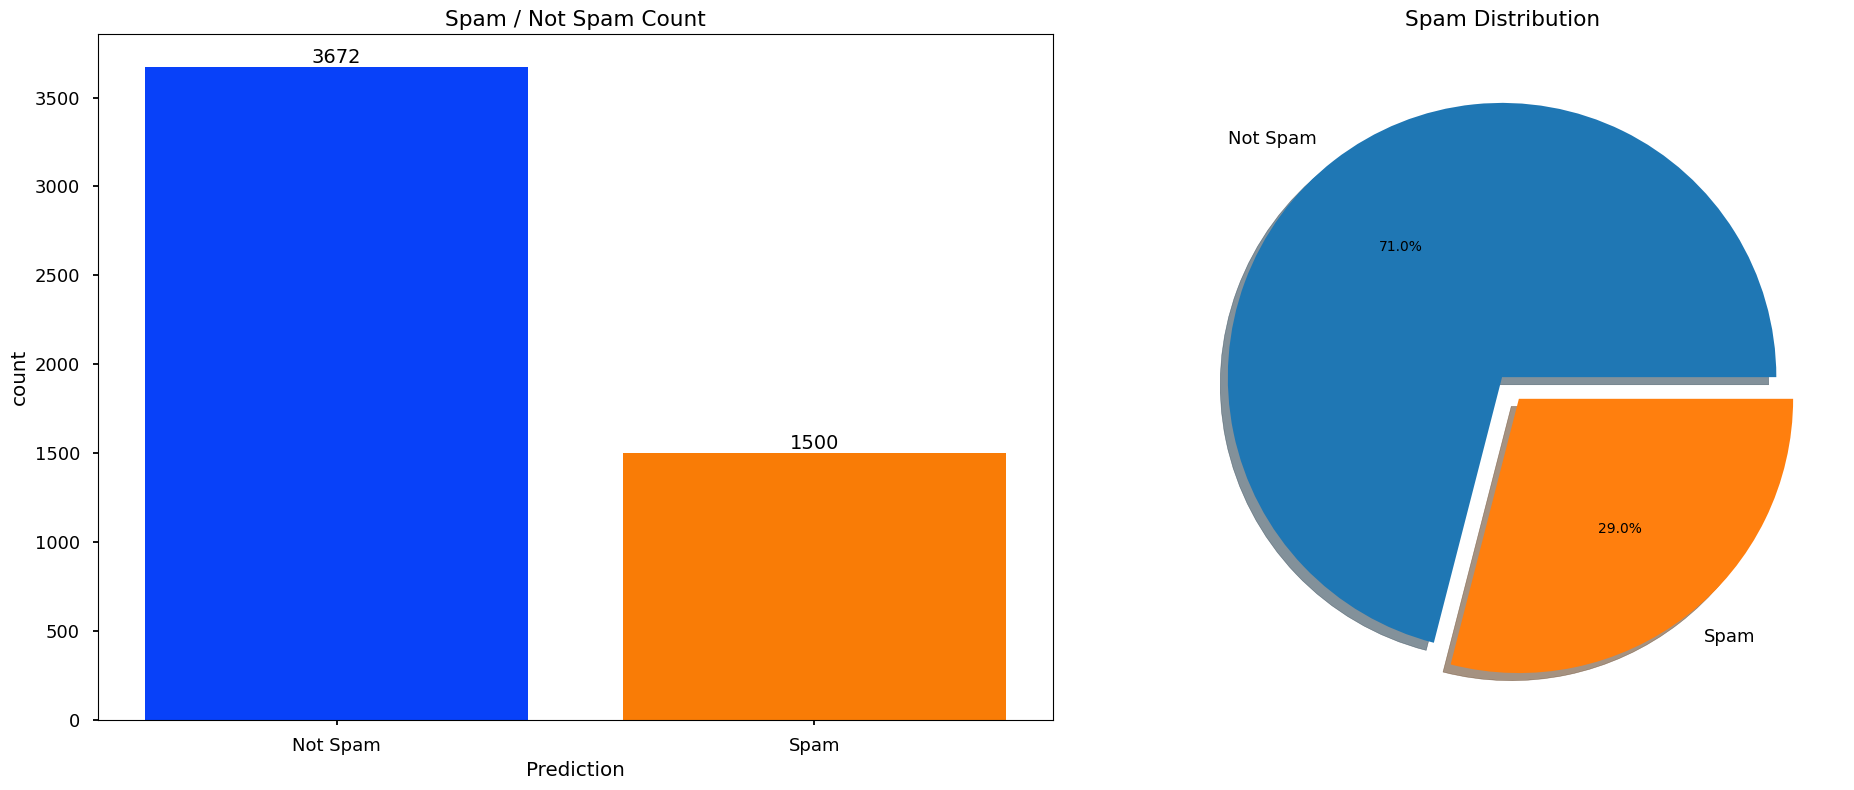

In [44]:
f, ax = plt.subplots(1, 2, figsize=(20, 8))

sns.countplot(x='Prediction', data=df, palette='bright', ax=ax[0], saturation=0.95)
ax[0].set_xticklabels(['Not Spam', 'Spam'])
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=14)
ax[0].set_title('Spam / Not Spam Count')

size = df['Prediction'].value_counts()
ax[1].pie(size.values, labels=['Not Spam', 'Spam'], explode=[0, 0.1],
          autopct='%1.1f%%', shadow=True)
ax[1].set_title('Spam Distribution')

plt.tight_layout()
plt.show()

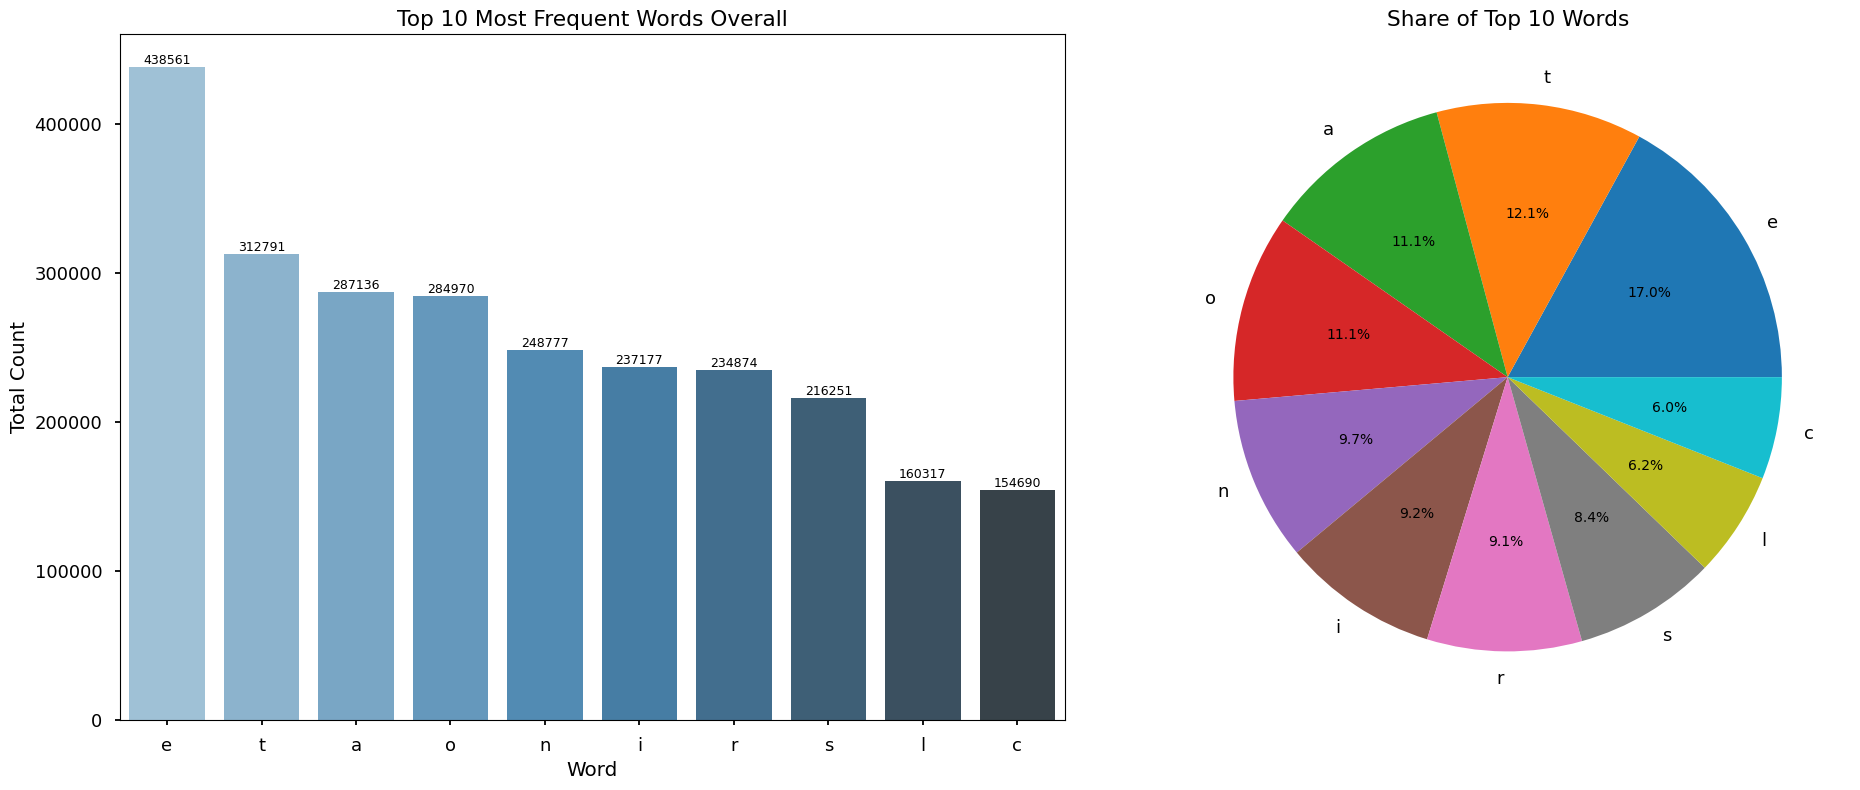

In [45]:
f, ax = plt.subplots(1, 2, figsize=(20, 8))

top10_words = df[word_cols].sum().nlargest(10).index.tolist()
word_totals = df[top10_words].sum().sort_values(ascending=False)

sns.barplot(x=word_totals.index, y=word_totals.values, palette='Blues_d', ax=ax[0])
ax[0].set_title('Top 10 Most Frequent Words Overall')
ax[0].set_xlabel('Word')
ax[0].set_ylabel('Total Count')
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=9, fmt='%.0f')


ax[1].pie(word_totals.values, labels=word_totals.index, autopct='%1.1f%%')
ax[1].set_title('Share of Top 10 Words')

plt.tight_layout()
plt.show()

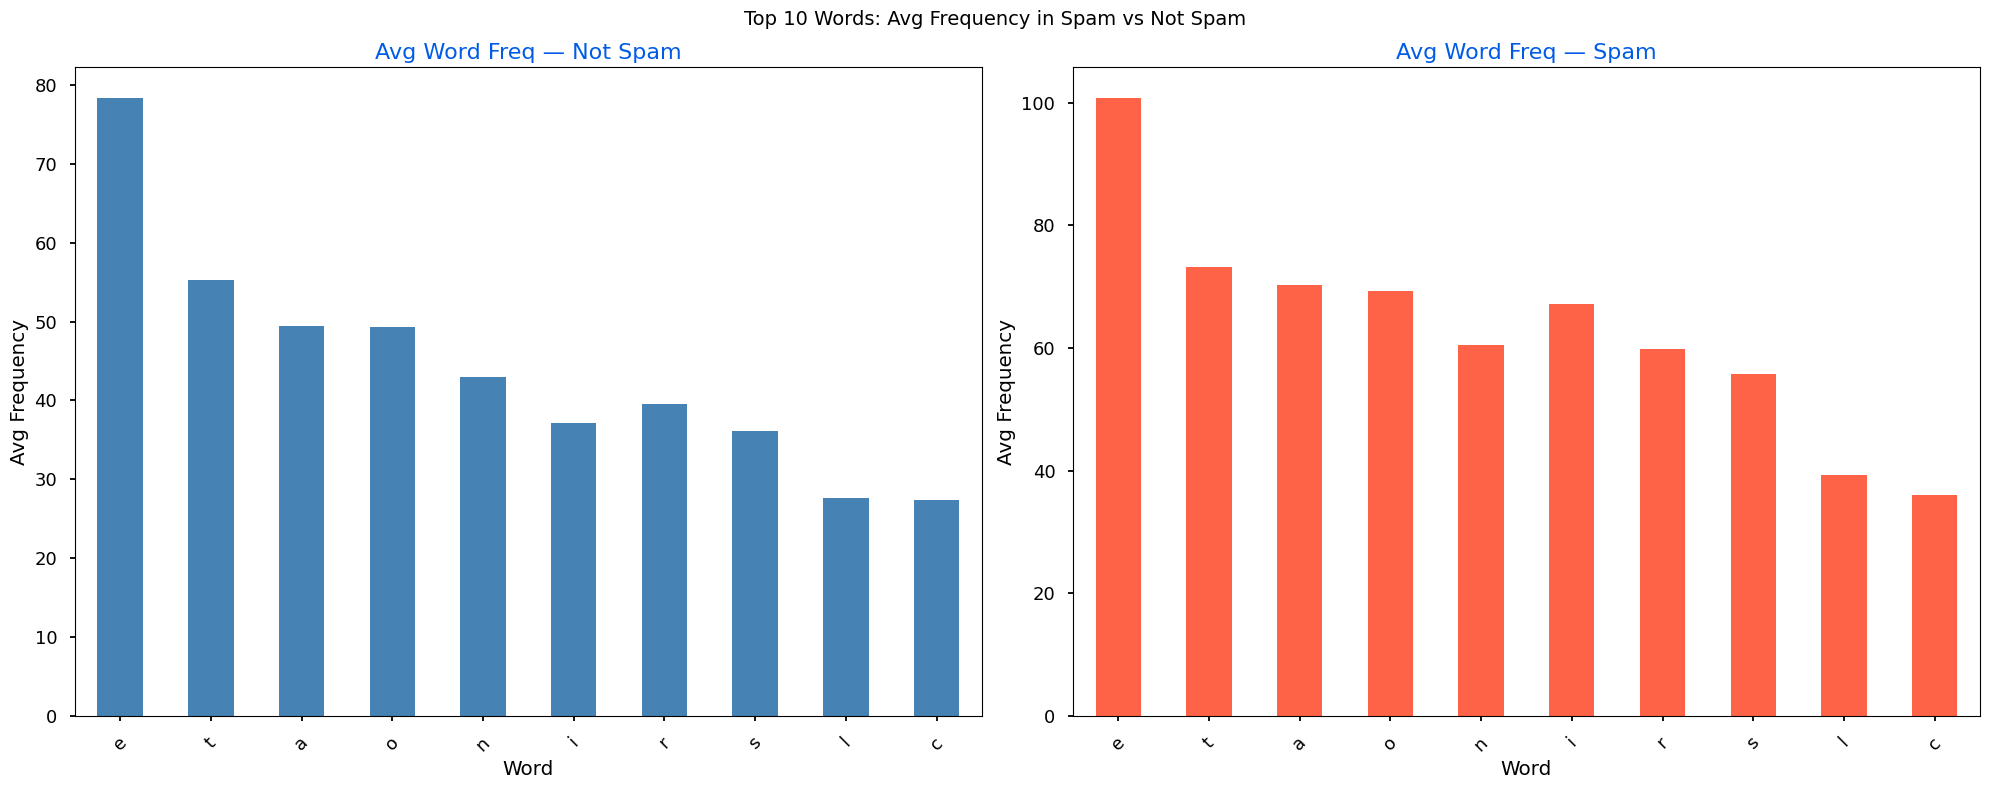

In [46]:
group_data = df.groupby('Prediction')[top10_words].mean()

f, ax = plt.subplots(1, 2, figsize=(20, 8))

group_data.T[0].plot(kind='bar', ax=ax[0], color='steelblue')
ax[0].set_title('Avg Word Freq — Not Spam', color='#005ce6', size=16)
ax[0].set_xlabel('Word')
ax[0].set_ylabel('Avg Frequency')
ax[0].tick_params(axis='x', rotation=45)

group_data.T[1].plot(kind='bar', ax=ax[1], color='tomato')
ax[1].set_title('Avg Word Freq — Spam', color='#005ce6', size=16)
ax[1].set_xlabel('Word')
ax[1].set_ylabel('Avg Frequency')
ax[1].tick_params(axis='x', rotation=45)

plt.suptitle('Top 10 Words: Avg Frequency in Spam vs Not Spam', fontsize=14)
plt.tight_layout()
plt.show()

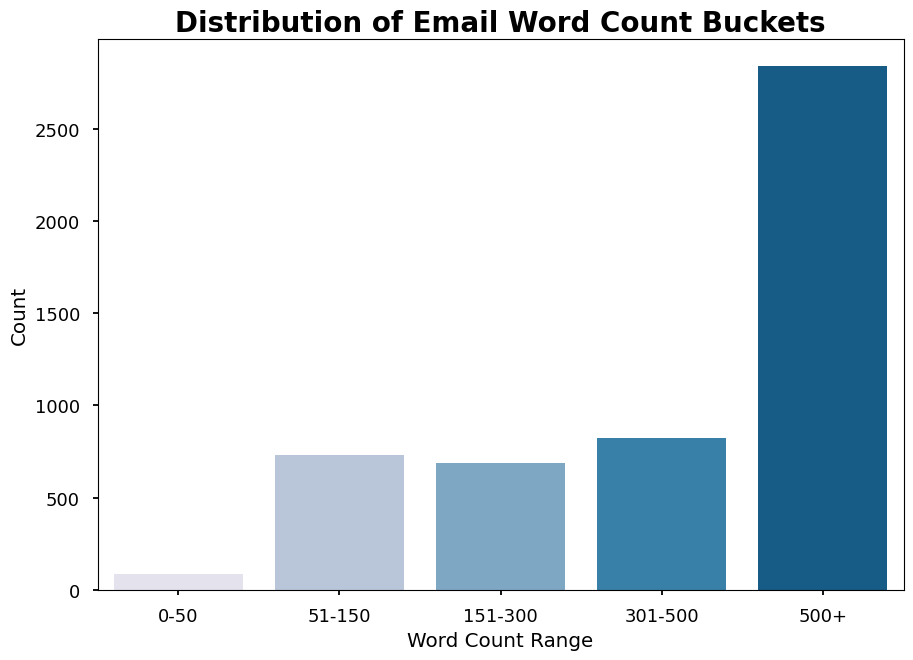

In [47]:
df['wc_bucket'] = pd.cut(df['total_word_count'],
                          bins=[0, 50, 150, 300, 500, df['total_word_count'].max()],
                          labels=['0-50', '51-150', '151-300', '301-500', '500+'])

plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('seaborn-v0_8-talk')
sns.countplot(x='wc_bucket', data=df, palette='PuBu')
plt.title('Distribution of Email Word Count Buckets', fontweight='bold', fontsize=20)
plt.xlabel('Word Count Range')
plt.ylabel('Count')
plt.show()

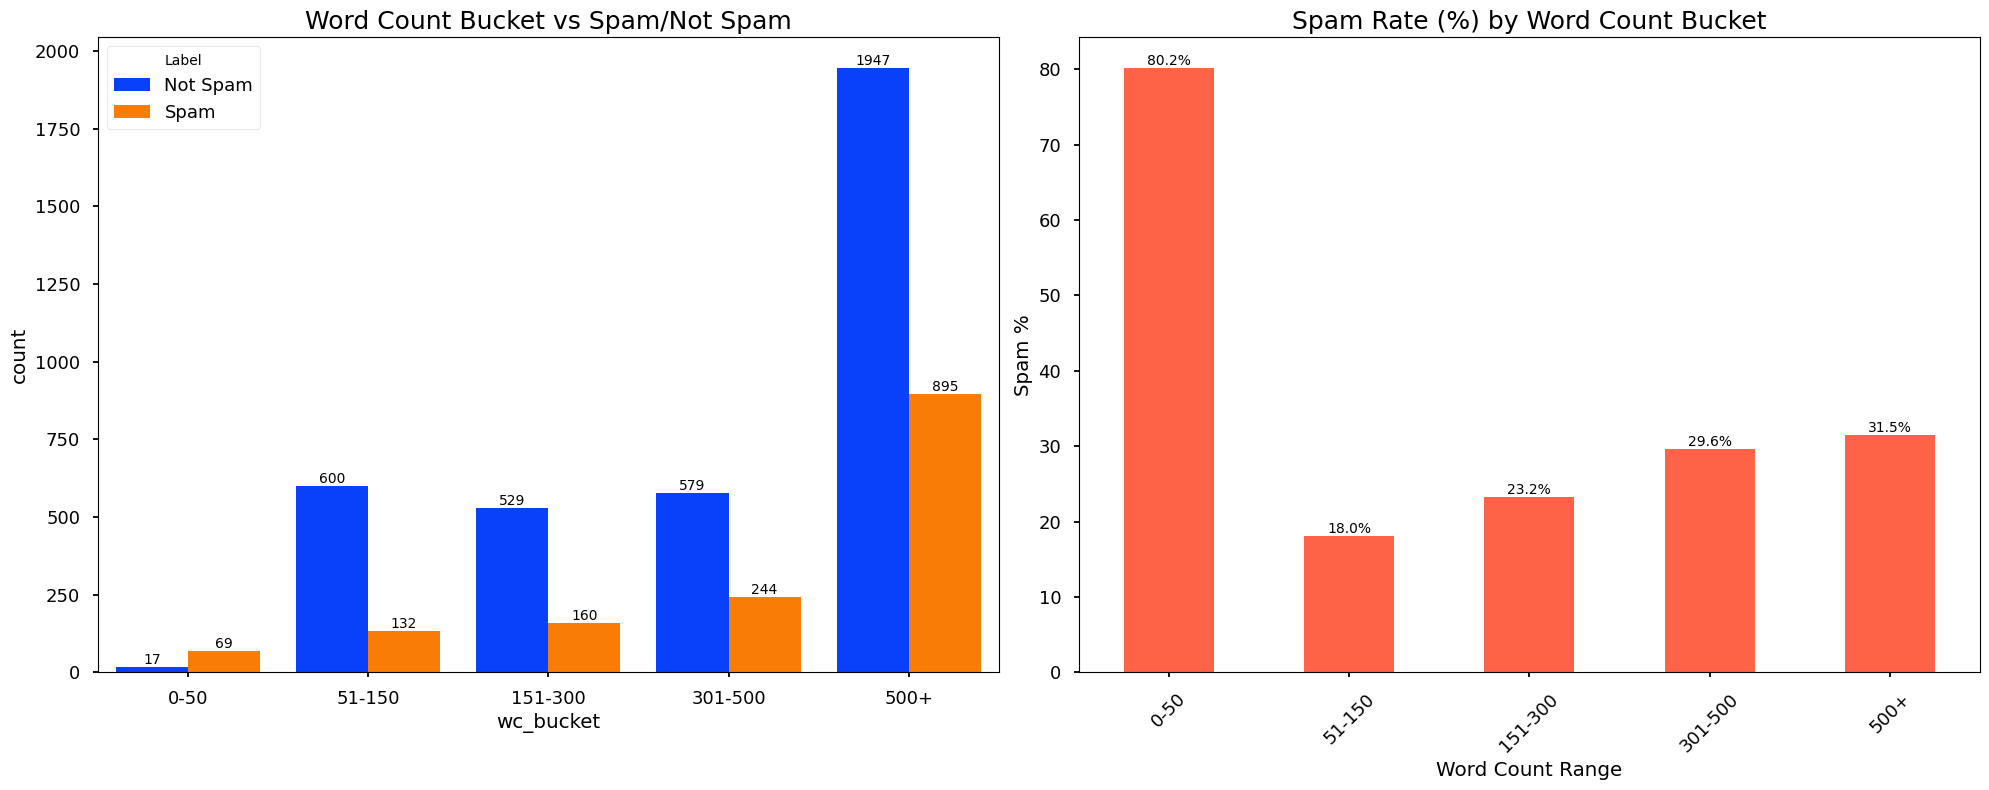

In [48]:
f, ax = plt.subplots(1, 2, figsize=(20, 8))

temp_df['wc_bucket'] = df['wc_bucket']

sns.countplot(x='wc_bucket', hue='Label', data=temp_df, palette='bright', saturation=0.95, ax=ax[0])
ax[0].set_title('Word Count Bucket vs Spam/Not Spam', color='black', size=18)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=10)

spam_rate = temp_df.groupby('wc_bucket')['Prediction'].mean() * 100
spam_rate.plot(kind='bar', color='tomato', ax=ax[1])
ax[1].set_title('Spam Rate (%) by Word Count Bucket', size=18)
ax[1].set_ylabel('Spam %')
ax[1].set_xlabel('Word Count Range')
ax[1].tick_params(axis='x', rotation=45)
for container in ax[1].containers:
    ax[1].bar_label(container, color='black', size=10, fmt='%.1f%%')

plt.tight_layout()
plt.show()

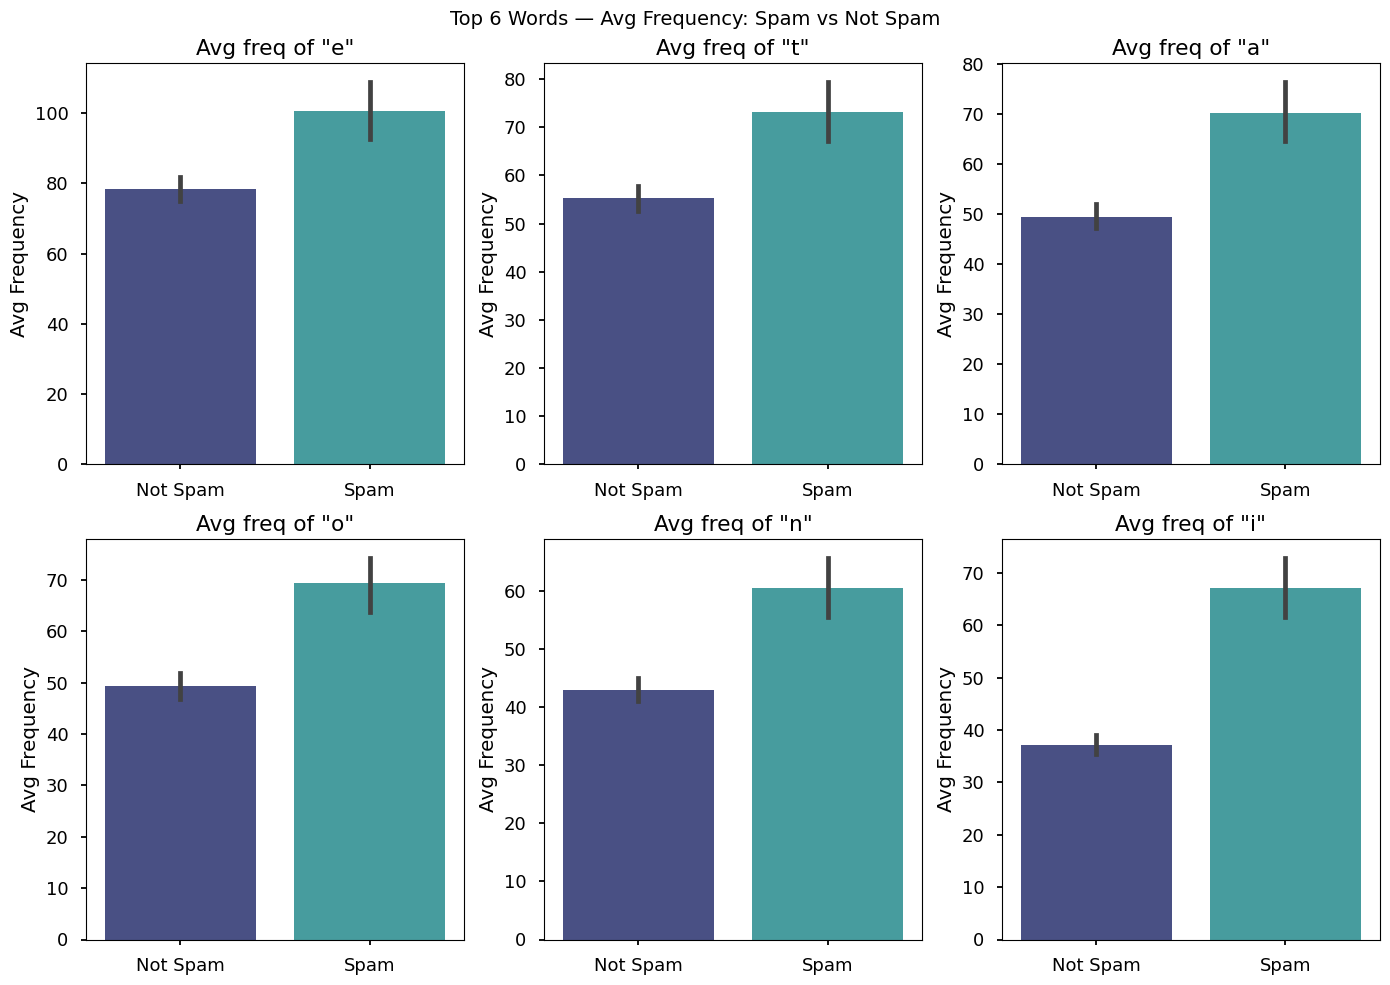

In [49]:
plt.figure(figsize=(14, 10))
top6 = df[word_cols].sum().nlargest(6).index.tolist()

for i, word in enumerate(top6):
    plt.subplot(2, 3, i+1)
    sns.barplot(x=temp_df['Label'], y=df[word], palette='mako')
    plt.title(f'Avg freq of "{word}"')
    plt.xlabel('')
    plt.ylabel('Avg Frequency')

plt.suptitle('Top 6 Words — Avg Frequency: Spam vs Not Spam', fontsize=14)
plt.tight_layout()
plt.show()

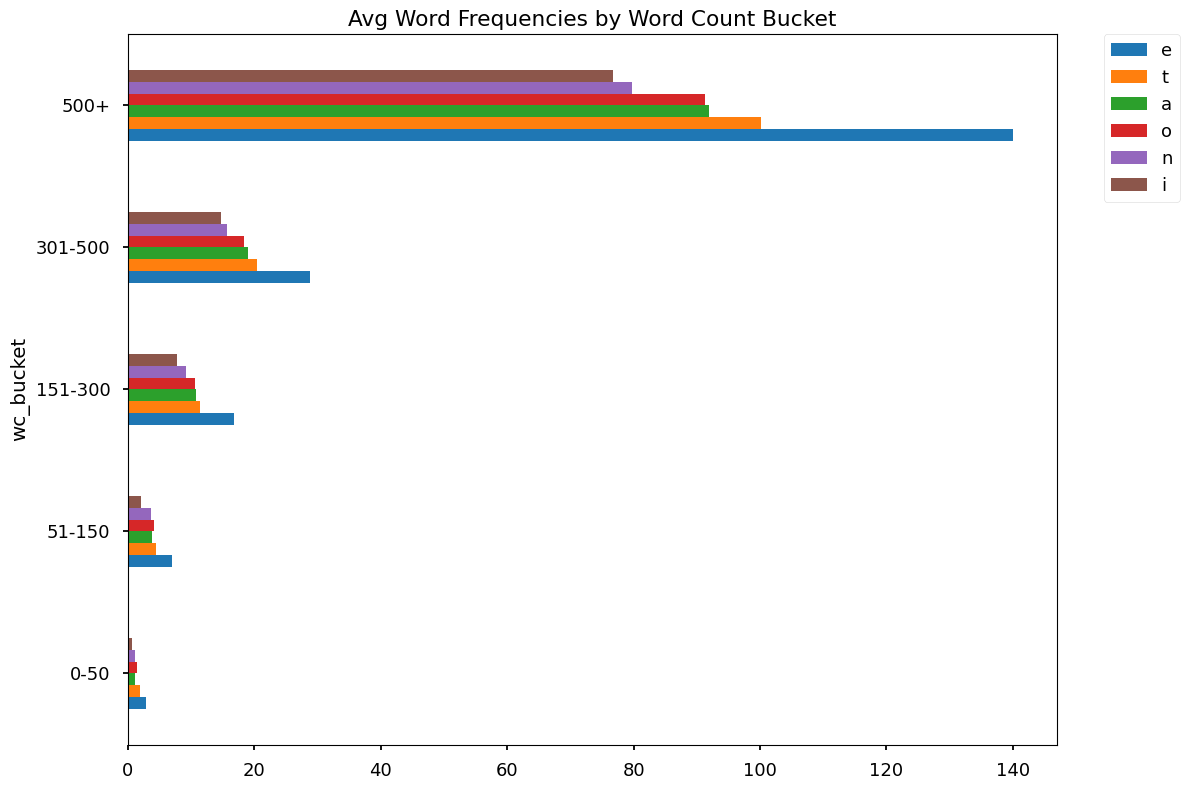

In [50]:
df.groupby('wc_bucket')[top6].mean().plot(kind='barh', figsize=(12, 8))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title('Avg Word Frequencies by Word Count Bucket')
plt.tight_layout()
plt.show()